# Analyse par Seuils — Zone Blanche / LOS / Couverture Technologique
**Projet FerroMobile / Flexy** — UTBM FEMTO-ST DISC/OMNI  
Ligne ferroviaire 785000 · Courpière–Ambert · 30 km

**Approche** : classification directe par seuils physiques (sans Machine Learning).

Le ML a été retiré : le label `zone_blanche` (et indirectement `los_category`) est défini
à partir des mêmes seuils que les features radio (`debit_adj_mbps`, `snr_adjusted_db`).
Entraîner un classifieur revient à ré-apprendre une règle déterministe — c'est du data leakage,
même en excluant les colonnes radio des features (les proxys comme `dist_ant_km` ou
`n_antennas` restent corrélés au seuil). On affiche donc directement la règle de seuil.

Ce notebook contient :
- **Partie 1** — Zone Blanche / Zone Couverte (seuil débit/SNR)
- **Partie 2** — Classification LOS (seuil terrain / visibilité)
- **Partie 3** — Couverture par technologie 2G / 3G / 4G / 5G (tronçons couverts)


In [2]:
# Installer les paquets manquants (si nécessaire)
%pip install -q pandas numpy matplotlib

# ── Imports ──────────────────────────────────────────────────────────────────
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Patch
import warnings
warnings.filterwarnings('ignore')

# ── Config ───────────────────────────────────────────────────────────────────
BASE_DIR = os.path.dirname(os.getcwd())
DATASET_PATH = os.path.join(BASE_DIR, "data", "processed", "dataset_enrichi.csv")

SEED = 42
np.random.seed(SEED)

print("✓ Imports OK")
print(f"✓ Dataset path : {DATASET_PATH}")
print(f"✓ Fichier trouvé : {os.path.exists(DATASET_PATH)}")


Note: you may need to restart the kernel to use updated packages.
✓ Imports OK
✓ Dataset path : /home/meyssem/Documents/ferromobile_project/data/processed/dataset_enrichi.csv
✓ Fichier trouvé : True


In [3]:
df = pd.read_csv(DATASET_PATH, low_memory=False)
print(f"Dataset brut : {df.shape[0]} lignes × {df.shape[1]} colonnes")
print(f"Points GPS uniques : {df['point_id'].nunique()}")
print(f"Générations : {sorted(df['generation'].unique())}")
print(f"Opérateurs   : {sorted(df['operateur'].unique())}")


Dataset brut : 90000 lignes × 73 colonnes
Points GPS uniques : 1500
Générations : ['2G', '3G', '4G', '5G']
Opérateurs   : ['BOUYGUES TELECOM', 'FREE MOBILE', 'ORANGE', 'SFR']


---
# Partie 1 — Zone Blanche / Zone Couverte (par seuil)


## Définition du seuil

**Alignement avec `enrich_data.py::recalculate_zone_blanche`** (définition finale et
faisant référence dans le pipeline — `prepare_data.py` calcule une version intermédiaire
basée sur `qualite_ok` à 3 critères débit/SNR/RTT, mais celle-ci est **écrasée** en aval
par `enrich_data.py`, qui ne garde que le critère débit seul).

Un point est en **zone blanche** s'il n'existe, parmi toutes les antennes **cellulaires
(2G/3G/4G/5G)** disponibles à ce point hors tunnel, **aucun débit utile** au-dessus du
seuil de service minimal (`DEBIT_VIABLE_MBPS`, **1 Mbps**).

Règle exacte du pipeline :
- LoRa est **exclu** du calcul de `best_debit` (généra·trice de débit non pertinente pour
  la définition cellulaire de la zone blanche — `enrich_data.py` l'exclut explicitement,
  même si LoRa a été supprimé du dataset final actuel).
- Tunnel → `zone_blanche = 1` systématiquement (absence totale de signal cellulaire par
  construction, ARCEP §2.3), **indépendamment du débit mesuré**.
- Hors tunnel → `zone_blanche = 1` si `max(debit_adj_mbps sur generation ∈ {2G,3G,4G,5G}) < SEUIL_DEBIT_MBPS`.

⚠️ Ne pas confondre avec `DEBIT_MIN_MBPS = 5.0` / `DEBIT_MIN_PAR_GEN`, qui servent au calcul
de `qualite_ok` (qualité de service par techno) — un concept différent de la couverture
binaire zone blanche / zone couverte.

## ⚙️ Paramètre expérimental — Seuil de débit augmenté

Modifier `SEUIL_DEBIT_MBPS` ci-dessous pour tester différents seuils et observer l'impact sur la zone blanche.

| Seuil | Interprétation |
|-------|----------------|
| **1 Mbps** | Seuil minimal actuel (pipeline `enrich_data.py`) |
| **3 Mbps** | Connexion confortable (streaming audio HD) |
| **5 Mbps** | Seuil `DEBIT_MIN_MBPS` du pipeline (qualité IoT) |
| **10 Mbps** | Vidéo HD temps réel (surveillance train) |
| **20 Mbps** | Haut débit ferroviaire (WiFi passagers) |

> **Observation attendue** : à seuil plus élevé → plus de points `best_debit < SEUIL` → plus de zone blanche hors tunnel.

In [4]:
SEUIL_DEBIT_MBPS = 1.0   # ← MODIFIEZ ICI pour tester : 1.0 / 3.0 / 5.0 / 10.0 / 20.0 Mbps

CELL_GENERATIONS = ['2G', '3G', '4G', '5G']

mask_cell_hors_tunnel = df['generation'].isin(CELL_GENERATIONS) & (~df['in_tunnel'])

best_debit_cell = (
    df.loc[mask_cell_hors_tunnel]
      .groupby('point_id')['debit_adj_mbps']
      .max()
)

by_point_zb = df.groupby('point_id').agg(
    lat         = ('lat',            'first'),
    lon         = ('lon',            'first'),
    distance_km = ('distance_km',    'first'),
    altitude_m  = ('altitude_m',     'first'),
    in_tunnel   = ('in_tunnel',      'max'),
    best_snr    = ('snr_adjusted_db','max'),
).reset_index()

# best_debit = meilleur débit cellulaire hors tunnel au point
# NaN → aucune antenne cellulaire hors tunnel = zone blanche par défaut
by_point_zb['best_debit'] = by_point_zb['point_id'].map(best_debit_cell).fillna(0.0)

# Règle : tunnel → toujours zone blanche | hors tunnel → best_debit < seuil
by_point_zb['zone_blanche_seuil'] = np.where(
    by_point_zb['in_tunnel'],
    1,
    (by_point_zb['best_debit'] < SEUIL_DEBIT_MBPS).astype(int)
)

by_point_zb = by_point_zb.sort_values('distance_km').reset_index(drop=True)

n_total    = len(by_point_zb)
n_blanche  = by_point_zb['zone_blanche_seuil'].sum()
n_couverte = n_total - n_blanche

print(f'Seuil utilisé          : {SEUIL_DEBIT_MBPS} Mbps')
print(f'Zone couverte          : {n_couverte:4d} points ({n_couverte/n_total*100:.1f}%)')
print(f'Zone blanche (+ tunnel): {n_blanche:4d} points ({n_blanche/n_total*100:.1f}%)')
print(f'  dont tunnels         : {by_point_zb["in_tunnel"].sum():4d} points (forcés zone blanche)')
print(f'  dont hors tunnel ZB  : {(by_point_zb["zone_blanche_seuil"] & ~by_point_zb["in_tunnel"]).sum():4d} points (débit < {SEUIL_DEBIT_MBPS} Mbps)')


Seuil utilisé          : 1.0 Mbps
Zone couverte          : 1474 points (98.3%)
Zone blanche (+ tunnel):   26 points (1.7%)
  dont tunnels         :   26 points (forcés zone blanche)
  dont hors tunnel ZB  :    0 points (débit < 1.0 Mbps)


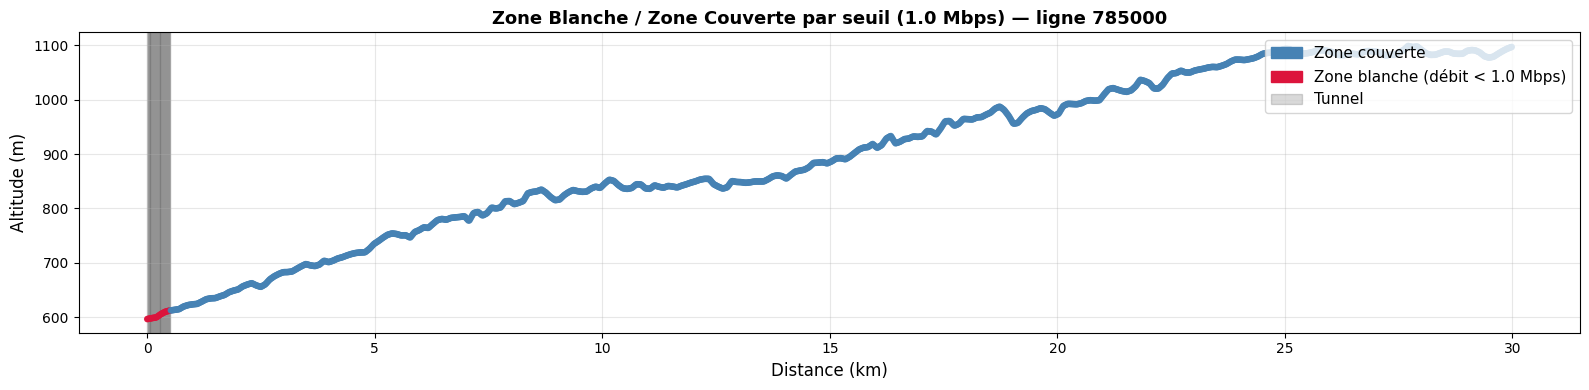

Carte sauvegardée : zone_blanche_seuil.png


In [5]:
fig, ax = plt.subplots(figsize=(16, 4))

colors = by_point_zb['zone_blanche_seuil'].map({0: 'steelblue', 1: 'crimson'})
ax.scatter(by_point_zb['distance_km'], by_point_zb['altitude_m'],
           c=colors, s=14, alpha=0.85, zorder=3)

# Tunnels en fond gris
for _, row in by_point_zb[by_point_zb['in_tunnel']].iterrows():
    ax.axvspan(row['distance_km'] - 0.01, row['distance_km'] + 0.01,
               alpha=0.15, color='black', zorder=1)

legend_els = [
    Patch(color='steelblue', label='Zone couverte'),
    Patch(color='crimson',   label=f'Zone blanche (débit < {SEUIL_DEBIT_MBPS} Mbps)'),
    Patch(color='black', alpha=0.15, label='Tunnel'),
]
ax.legend(handles=legend_els, fontsize=11, loc='upper right')
ax.set_xlabel('Distance (km)', fontsize=12)
ax.set_ylabel('Altitude (m)', fontsize=12)
ax.set_title(f'Zone Blanche / Zone Couverte par seuil ({SEUIL_DEBIT_MBPS} Mbps) — ligne 785000',
             fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('zone_blanche_seuil.png', dpi=150, bbox_inches='tight')
plt.show()
print("Carte sauvegardée : zone_blanche_seuil.png")


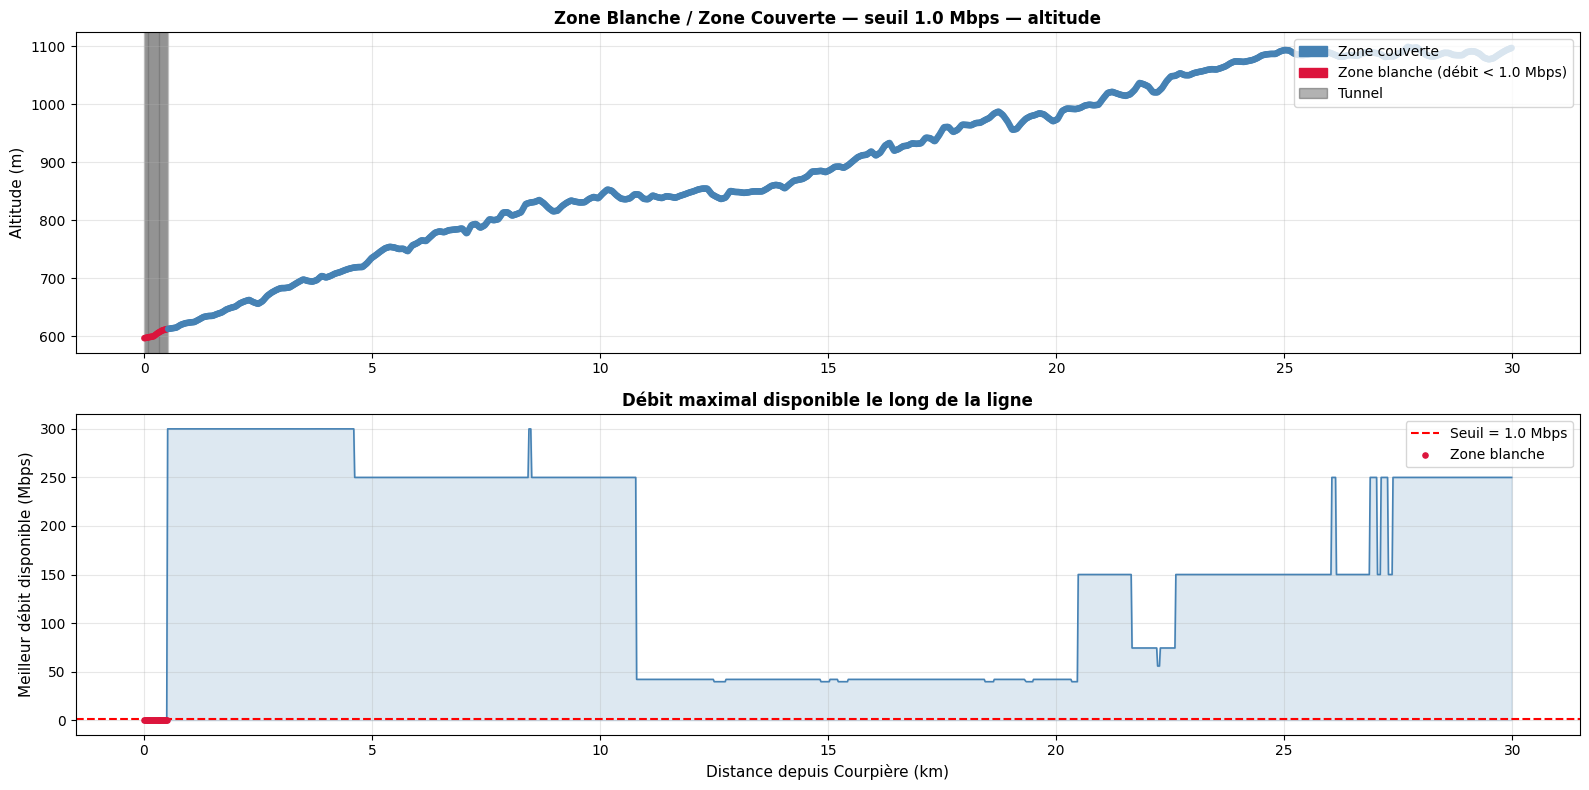

Sauvegardé : zone_blanche_combined.png


In [6]:
# Même vue que ci-dessus mais avec le débit comme axe Y
# → permet de voir directement quels points sont sous le seuil
fig, axes = plt.subplots(2, 1, figsize=(16, 8))

# ── Figure 1 : scatter altitude (comme la carte principale) ─────────────────
ax = axes[0]
colors = by_point_zb['zone_blanche_seuil'].map({0: 'steelblue', 1: 'crimson'})
ax.scatter(by_point_zb['distance_km'], by_point_zb['altitude_m'],
           c=colors, s=14, alpha=0.85, zorder=3)
for _, row in by_point_zb[by_point_zb['in_tunnel']].iterrows():
    ax.axvspan(row['distance_km'] - 0.01, row['distance_km'] + 0.01,
               alpha=0.15, color='black', zorder=1)
from matplotlib.patches import Patch as _Patch
legend_els = [
    _Patch(color='steelblue', label='Zone couverte'),
    _Patch(color='crimson',   label=f'Zone blanche (débit < {SEUIL_DEBIT_MBPS} Mbps)'),
    _Patch(color='black', alpha=0.3, label='Tunnel'),
]
ax.legend(handles=legend_els, fontsize=10, loc='upper right')
ax.set_ylabel('Altitude (m)', fontsize=11)
ax.set_title(f'Zone Blanche / Zone Couverte — seuil {SEUIL_DEBIT_MBPS} Mbps — altitude', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)

# ── Figure 2 : scatter débit — même code couleur ────────────────────────────
ax2 = axes[1]
ax2.fill_between(by_point_zb['distance_km'], by_point_zb['best_debit'],
                 alpha=0.18, color='steelblue')
ax2.plot(by_point_zb['distance_km'], by_point_zb['best_debit'],
         color='steelblue', lw=1.2)
ax2.axhline(SEUIL_DEBIT_MBPS, color='red', lw=1.5, ls='--',
            label=f'Seuil = {SEUIL_DEBIT_MBPS} Mbps')
mask_blanche = by_point_zb['zone_blanche_seuil'] == 1
ax2.scatter(by_point_zb.loc[mask_blanche, 'distance_km'],
            by_point_zb.loc[mask_blanche, 'best_debit'],
            color='crimson', s=14, zorder=4, label='Zone blanche')
ax2.set_xlabel('Distance depuis Courpière (km)', fontsize=11)
ax2.set_ylabel('Meilleur débit disponible (Mbps)', fontsize=11)
ax2.set_title('Débit maximal disponible le long de la ligne', fontsize=12, fontweight='bold')
ax2.legend(fontsize=10, loc='upper right')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('zone_blanche_combined.png', dpi=150, bbox_inches='tight')
plt.show()
print('Sauvegardé : zone_blanche_combined.png')


### Comparaison multi-seuils — impact sur la zone blanche


Seuil (Mbps)      ZB total  dont hors tunnel  Zone couverte  % blanche
----------------------------------------------------------------------
1.0                     26                 0           1474       1.7%  ← pipeline actuel
3.0                     26                 0           1474       1.7%
5.0                     26                 0           1474       1.7%
10.0                    26                 0           1474       1.7%
20.0                    26                 0           1474       1.7%


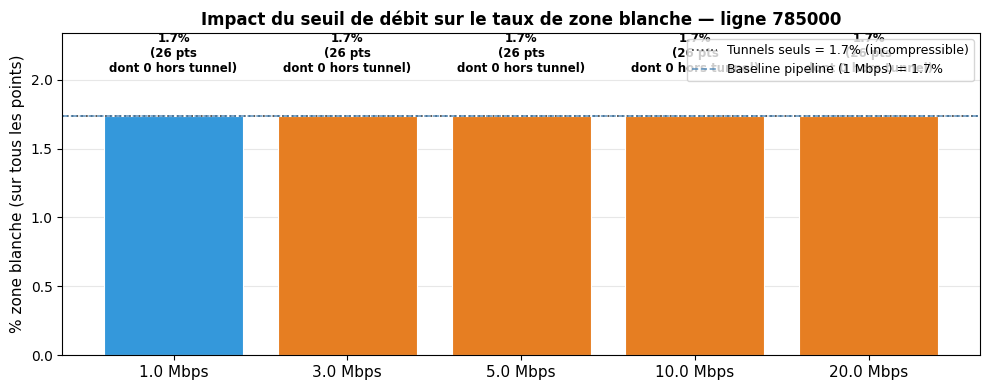

Sauvegardé : comparaison_seuils_zone_blanche.png


In [7]:
# ── Comparaison multi-seuils — impact sur le taux de zone blanche ──────────
# Utilise best_debit déjà calculé ci-dessus (indépendant du seuil)
SEUILS_A_TESTER = [1.0, 3.0, 5.0, 10.0, 20.0]

print(f"{'Seuil (Mbps)':<15} {'ZB total':>10} {'dont hors tunnel':>17} {'Zone couverte':>14} {'% blanche':>10}")
print('-' * 70)

resultats_seuils = []
for s in SEUILS_A_TESTER:
    zb_arr = np.where(
        by_point_zb['in_tunnel'],
        1,
        (by_point_zb['best_debit'] < s).astype(int)
    )
    n_zb_total    = int(zb_arr.sum())
    n_zb_hors     = int(((by_point_zb['best_debit'] < s) & ~by_point_zb['in_tunnel']).sum())
    n_couv        = n_total - n_zb_total
    pct           = n_zb_total / n_total * 100
    marker = '  ← pipeline actuel' if abs(s - 1.0) < 0.01 else ''
    print(f"{s:<15.1f} {n_zb_total:>10} {n_zb_hors:>17} {n_couv:>14} {pct:>9.1f}%{marker}")
    resultats_seuils.append((s, n_zb_total, n_zb_hors, pct))

# Graphique
fig, ax = plt.subplots(figsize=(10, 4))
seuils_vals = [r[0] for r in resultats_seuils]
pct_vals    = [r[3] for r in resultats_seuils]
n_tunnel    = int(by_point_zb['in_tunnel'].sum())
pct_tunnel  = n_tunnel / n_total * 100

bars = ax.bar(range(len(seuils_vals)), pct_vals,
              color=['#3498db' if abs(s-1.0)<0.01 else '#e74c3c' if p>60 else '#e67e22'
                     for s, p in zip(seuils_vals, pct_vals)],
              edgecolor='white', linewidth=0.8, zorder=2)

for bar, (s, n_zb, n_hors, pct) in zip(bars, resultats_seuils):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{pct:.1f}%\n({n_zb} pts\ndont {n_hors} hors tunnel)',
            ha='center', va='bottom', fontsize=8.5, fontweight='bold')

# Ligne tunnel fixe (incompressible)
ax.axhline(pct_tunnel, color='black', lw=1.3, ls=':', alpha=0.7,
           label=f'Tunnels seuls = {pct_tunnel:.1f}% (incompressible)')
# Ligne baseline pipeline
ax.axhline(resultats_seuils[0][3], color='steelblue', lw=1.2, ls='--', alpha=0.8,
           label=f'Baseline pipeline (1 Mbps) = {resultats_seuils[0][3]:.1f}%')

ax.set_xticks(range(len(seuils_vals)))
ax.set_xticklabels([f'{s} Mbps' for s in seuils_vals], fontsize=11)
ax.set_ylabel('% zone blanche (sur tous les points)', fontsize=11)
ax.set_ylim(0, max(pct_vals) * 1.35)
ax.set_title('Impact du seuil de débit sur le taux de zone blanche — ligne 785000',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis='y', zorder=0)
plt.tight_layout()
plt.savefig('comparaison_seuils_zone_blanche.png', dpi=150, bbox_inches='tight')
plt.show()
print('Sauvegardé : comparaison_seuils_zone_blanche.png')


---
# Partie 2 — Classification LOS (par seuil terrain)


## Définition et correction méthodologique

`los_category` est calculé dans le pipeline (`prepare_data.py::check_los_graduel`) pour
**chaque paire point↔antenne** à partir du profil de terrain réel (EU-DEM) et du critère
de la zone de Fresnel — ce n'est pas une métrique radio simulée, c'est un calcul géométrique
déterministe : `0=Tunnel · 1=NLOS bloqué (obstruction totale) · 2=Partiel (zone de Fresnel
obstruée) · 3=LOS dégagé`.

**Pourquoi l'altitude compte** : entre le train et une antenne, si le relief le long du
trajet dépasse la ligne droite reliant les deux (corrigée de la zone de Fresnel), le signal
est bloqué ou dégradé. C'est ce calcul géométrique qui produit la catégorie LOS.

**⚠️ Point important** : un point GPS "voit" plusieurs antennes (jusqu'à 88 candidates dans
le rayon de recherche), donc `los_category` n'est pas une propriété unique du point — elle
varie par antenne. Une agrégation par **pire cas** (`.min()`, une seule antenne lointaine
bloquée suffit à classer tout le point en NLOS) ou par **meilleur cas** (`.max()`) déforme
fortement la distribution réelle. On utilise donc :
- la **distribution brute** (toutes les paires point×antenne) pour les statistiques globales,
  qui correspond à ta référence (≈46% LOS dégagé / 12% partiel / 40% NLOS / 2% tunnel) ;
- le **mode** (catégorie la plus fréquente parmi les antennes disponibles à ce point) pour
  la carte le long de la ligne, qui donne une vue représentative sans biais pire/meilleur cas.


In [8]:
LOS_LABELS = {0: 'Tunnel', 1: 'NLOS bloqué', 2: 'Partiel/dégradé', 3: 'LOS dégagé'}
COLORS_LOS = {0: '#7f8c8d', 1: '#c0392b', 2: '#e67e22', 3: '#27ae60'}
ATTEN_DB = {0: float('-inf'), 1: -15, 2: -8, 3: 0}   # atténuation indicative par catégorie

# Distribution brute (point × antenne) — référence pour les statistiques globales
dist_brute = df['los_category'].value_counts(normalize=True).sort_index() * 100

print("Distribution LOS brute (toutes paires point × antenne) :")
for cat, label in LOS_LABELS.items():
    pct = dist_brute.get(cat, 0.0)
    print(f"  {cat} — {label:18s} : {pct:5.1f}%")

# Agrégation par point — mode (catégorie la plus fréquente parmi les antennes disponibles)
# (.min() = pire cas et .max() = meilleur cas déforment la distribution ; le mode est représentatif)
by_point_los = df.groupby('point_id').agg(
    lat          = ('lat',          'first'),
    lon          = ('lon',          'first'),
    distance_km  = ('distance_km',  'first'),
    altitude_m   = ('altitude_m',   'first'),
    in_tunnel    = ('in_tunnel',    'max'),
    dist_ant_km  = ('dist_ant_km',  'min'),
).reset_index()

mode_los = df.groupby('point_id')['los_category'].agg(lambda x: x.mode().iloc[0])
by_point_los = by_point_los.merge(mode_los.rename('los_category'), on='point_id')
by_point_los = by_point_los.sort_values('distance_km').reset_index(drop=True)

print("\nDistribution LOS par point (mode — catégorie représentative) :")
for cat, label in LOS_LABELS.items():
    n = (by_point_los['los_category'] == cat).sum()
    print(f"  {cat} — {label:18s} : {n:4d} points ({n/len(by_point_los)*100:.1f}%)")


Distribution LOS brute (toutes paires point × antenne) :
  0 — Tunnel             :   1.7%
  1 — NLOS bloqué        :  41.0%
  2 — Partiel/dégradé    :  10.5%
  3 — LOS dégagé         :  46.8%

Distribution LOS par point (mode — catégorie représentative) :
  0 — Tunnel             :   26 points (1.7%)
  1 — NLOS bloqué        :  693 points (46.2%)
  2 — Partiel/dégradé    :  128 points (8.5%)
  3 — LOS dégagé         :  653 points (43.5%)


### Carte-résumé — distribution LOS et atténuation associée


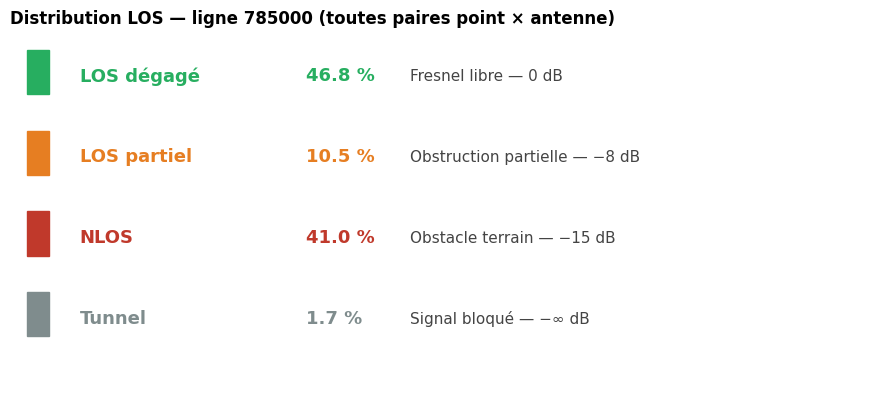

Sauvegardé : los_resume_pct_db.png


In [9]:
fig, ax = plt.subplots(figsize=(9, 4.2))
ax.axis('off')

row_labels = {0: 'Tunnel', 1: 'NLOS', 2: 'LOS partiel', 3: 'LOS dégagé'}
row_desc = {
    0: 'Signal bloqué — −∞ dB',
    1: 'Obstacle terrain — −15 dB',
    2: 'Obstruction partielle — −8 dB',
    3: 'Fresnel libre — 0 dB',
}
row_order = [3, 2, 1, 0]   # même ordre que la slide de référence

y0 = 0.88
dy = 0.22
for i, cat in enumerate(row_order):
    y = y0 - i * dy
    pct = dist_brute.get(cat, 0.0)
    color = COLORS_LOS[cat]
    ax.add_patch(plt.Rectangle((0.02, y - 0.05), 0.025, 0.12,
                                transform=ax.transAxes, color=color, clip_on=False))
    ax.text(0.08, y, row_labels[cat], transform=ax.transAxes,
            fontsize=13, fontweight='bold', color=color, va='center')
    ax.text(0.34, y, f"{pct:.1f} %", transform=ax.transAxes,
            fontsize=13, fontweight='bold', color=color, va='center')
    ax.text(0.46, y, row_desc[cat], transform=ax.transAxes,
            fontsize=11, color='#444444', va='center')

ax.set_title('Distribution LOS — ligne 785000 (toutes paires point × antenne)',
             fontsize=12, fontweight='bold', loc='left')
plt.tight_layout()
plt.savefig('los_resume_pct_db.png', dpi=150, bbox_inches='tight')
plt.show()
print("Sauvegardé : los_resume_pct_db.png")


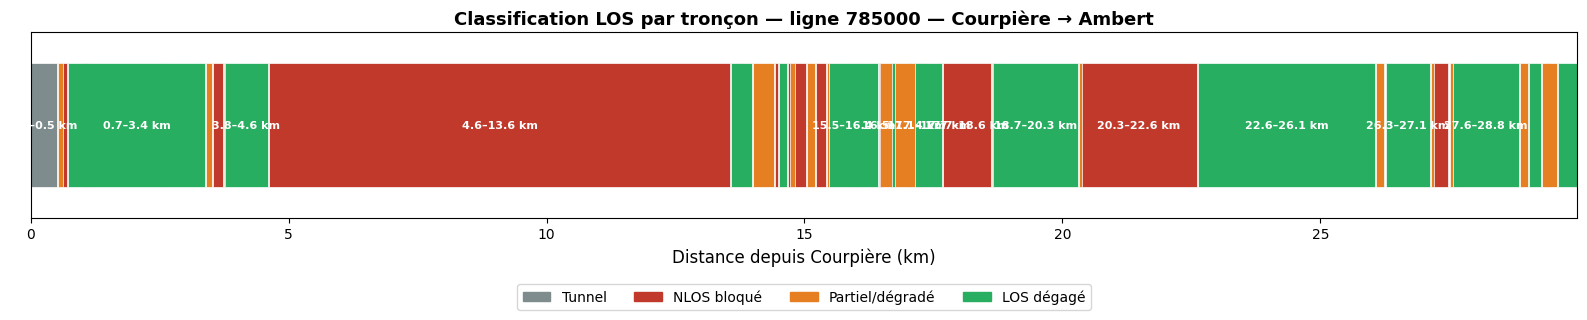

Carte sauvegardée : los_carte_troncons.png

Tronçons LOS (mode par point) :

Tunnel — 1 tronçon(s) :
   km   0.00 → km   0.50  ( 0.50 km)

NLOS bloqué — 15 tronçon(s) :
   km   0.56 → km   0.70  ( 0.14 km)
   km   1.04 → km   1.12  ( 0.08 km)
   km   3.54 → km   3.72  ( 0.18 km)
   km   4.62 → km  13.56  ( 8.94 km)
   km  14.42 → km  14.48  ( 0.06 km)
   km  14.68 → km  15.02  ( 0.34 km)
   km  15.22 → km  15.42  ( 0.20 km)
   km  16.44 → km  16.50  ( 0.06 km)
   km  16.98 → km  17.06  ( 0.08 km)
   km  17.68 → km  18.62  ( 0.94 km)
   km  20.34 → km  22.60  ( 2.26 km)
   km  27.19 → km  27.49  ( 0.30 km)
   km  28.89 → km  28.97  ( 0.08 km)
   km  29.35 → km  29.45  ( 0.10 km)

Partiel/dégradé — 19 tronçon(s) :
   km   0.52 → km   0.62  ( 0.10 km)
   km   3.40 → km   3.52  ( 0.12 km)
   km  13.68 → km  13.78  ( 0.10 km)
   km  14.00 → km  14.40  ( 0.40 km)
   km  14.72 → km  14.82  ( 0.10 km)
   km  15.04 → km  15.20  ( 0.16 km)
   km  15.98 → km  16.04  ( 0.06 km)
   km  16.46 → km  

In [10]:
# Carte de ligne groupée en tronçons lisibles (mode par point, segments contigus)
def get_troncons_los(by_point_los, cat, gap_max=0.15):
    sub = by_point_los[by_point_los['los_category'] == cat].sort_values('distance_km')
    pts = sub['distance_km'].values
    if len(pts) == 0:
        return []
    troncons = []
    start = prev = pts[0]
    for p in pts[1:]:
        if p - prev > gap_max:
            troncons.append((start, prev))
            start = p
        prev = p
    troncons.append((start, prev))
    return troncons

fig, ax = plt.subplots(figsize=(16, 3.6))

all_segs = []
for cat in [0, 1, 2, 3]:
    for (a, b) in get_troncons_los(by_point_los, cat):
        all_segs.append((a, b, cat))

for (a, b, cat) in all_segs:
    width = max(b - a, 0.05)
    ax.barh(0, width, left=a, height=0.8, color=COLORS_LOS[cat],
            edgecolor='white', linewidth=0.5, zorder=2)

# Annotations en deux rangées alternées pour éviter les chevauchements sur les segments courts
wide_segs = [s for s in all_segs if (s[1]-s[0]) > 0.5]
for i, (a, b, cat) in enumerate(sorted(wide_segs)):
    y_off = 0 if (i % 2 == 0) else 0
    ax.text((a+b)/2, 0, f'{a:.1f}–{b:.1f} km',
            ha='center', va='center', fontsize=8, color='white', fontweight='bold', zorder=3)

handles = [mpatches.Patch(color=COLORS_LOS[c], label=LOS_LABELS[c]) for c in [0,1,2,3]]
ax.legend(handles=handles, fontsize=10, loc='upper center',
          bbox_to_anchor=(0.5, -0.32), ncol=4)

ax.set_xlim(by_point_los['distance_km'].min(), by_point_los['distance_km'].max())
ax.set_ylim(-0.6, 0.6)
ax.set_yticks([])
ax.set_xlabel('Distance depuis Courpière (km)', fontsize=12)
ax.set_title('Classification LOS par tronçon — ligne 785000 — Courpière → Ambert',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('los_carte_troncons.png', dpi=150, bbox_inches='tight')
plt.show()
print("Carte sauvegardée : los_carte_troncons.png")

print("\nTronçons LOS (mode par point) :")
for cat in [0,1,2,3]:
    troncons = get_troncons_los(by_point_los, cat)
    print(f"\n{LOS_LABELS[cat]} — {len(troncons)} tronçon(s) :")
    for (a,b) in troncons:
        if b - a > 0.05:
            print(f"   km {a:6.2f} → km {b:6.2f}  ({b-a:5.2f} km)")


---
# Partie 3 — Couverture par Technologie (2G / 3G / 4G / 5G)


## Objectif

Identifier, pour chaque génération, **quels tronçons de la ligne** sont couverts
(au-dessus du seuil de débit) et avec quelle qualité, en prenant le meilleur opérateur
disponible à chaque point.


In [11]:
COLORS_GEN = {'2G': '#e74c3c', '3G': '#f39c12', '4G': '#2980b9', '5G': '#27ae60'}

gen_coverage = df.groupby(['point_id', 'generation']).agg(
    distance_km  = ('distance_km',    'first'),
    altitude_m   = ('altitude_m',     'first'),
    lat          = ('lat',            'first'),
    lon          = ('lon',            'first'),
    in_tunnel    = ('in_tunnel',      'first'),
    best_debit   = ('debit_adj_mbps', 'max'),
    best_snr     = ('snr_adjusted_db','max'),
).reset_index()

pivot_debit = gen_coverage.pivot_table(
    index='point_id', columns='generation', values='best_debit', aggfunc='max'
).fillna(0)

geo = df.groupby('point_id').agg(
    distance_km = ('distance_km', 'first'),
    altitude_m  = ('altitude_m',  'first'),
    lat         = ('lat',         'first'),
    lon         = ('lon',         'first'),
    in_tunnel   = ('in_tunnel',   'first'),
).reset_index()

pivot_debit = pivot_debit.reset_index().merge(geo, on='point_id')
pivot_debit = pivot_debit.sort_values('distance_km').reset_index(drop=True)

print(f"Seuil de couverture utilisé : {SEUIL_DEBIT_MBPS} Mbps\n")
print("Points couverts par génération :")
for gen in ['2G','3G','4G','5G']:
    if gen in pivot_debit.columns:
        n = (pivot_debit[gen] >= SEUIL_DEBIT_MBPS).sum()
        moy = pivot_debit[gen][pivot_debit[gen] >= SEUIL_DEBIT_MBPS].mean()
        print(f"  {gen} : {n:4d} points couverts | débit moyen : {moy:6.1f} Mbps")


Seuil de couverture utilisé : 1.0 Mbps

Points couverts par génération :
  2G :    0 points couverts | débit moyen :    nan Mbps
  3G : 1474 points couverts | débit moyen :    7.2 Mbps
  4G : 1474 points couverts | débit moyen :   55.7 Mbps
  5G :  942 points couverts | débit moyen :  231.7 Mbps


### Diagrammes séparés par génération — tronçon Courpière–Ambert couvert

Pour chaque technologie (2G, 3G, 4G, 5G), un diagramme dédié montre le débit le long
de la ligne, le seuil de couverture (ligne rouge), et surligne en couleur le(s)
tronçon(s) **réellement couverts** entre Courpière (km 0) et Ambert (km 30).


In [12]:
DIST_MIN = pivot_debit['distance_km'].min()
DIST_MAX = pivot_debit['distance_km'].max()
GAP_MAX_KM = 0.1   # au-delà de cet écart entre deux points couverts, on coupe le tronçon

def get_troncons(pivot_debit, gen, seuil, gap_max=GAP_MAX_KM):
    """Retourne la liste des tronçons contigus couverts : [(km_debut, km_fin, debit_moyen), ...]"""
    mask = (pivot_debit[gen] >= seuil) & (~pivot_debit['in_tunnel'])
    sub = pivot_debit.loc[mask, ['distance_km', gen]].sort_values('distance_km').reset_index(drop=True)
    if sub.empty:
        return []

    troncons = []
    start_idx = 0
    for i in range(1, len(sub)):
        if sub.loc[i, 'distance_km'] - sub.loc[i-1, 'distance_km'] > gap_max:
            seg = sub.iloc[start_idx:i]
            troncons.append((seg['distance_km'].iloc[0], seg['distance_km'].iloc[-1], seg[gen].mean()))
            start_idx = i
    seg = sub.iloc[start_idx:]
    troncons.append((seg['distance_km'].iloc[0], seg['distance_km'].iloc[-1], seg[gen].mean()))
    return troncons

def plot_couverture_generation(pivot_debit, gen, color, seuil=SEUIL_DEBIT_MBPS):
    """Diagramme dédié : débit le long de la ligne + tronçon(s) couvert(s) annotés (km début→fin, débit moyen)."""
    fig, ax = plt.subplots(figsize=(16, 4.2))

    if gen not in pivot_debit.columns:
        ax.text(0.5, 0.5, f'{gen} — pas de données', ha='center', va='center',
                transform=ax.transAxes, fontsize=12)
        return

    mask_tunnel = pivot_debit['in_tunnel']
    mask_ok     = (~mask_tunnel) & (pivot_debit[gen] >= seuil)
    mask_nok    = (~mask_tunnel) & (pivot_debit[gen] < seuil)

    troncons = get_troncons(pivot_debit, gen, seuil)

    # Bande de fond colorée = tronçon(s) couvert(s)
    for (a, b, _) in troncons:
        ax.axvspan(a, b, color=color, alpha=0.15, zorder=0)

    # Courbe de débit
    ax.plot(pivot_debit['distance_km'], pivot_debit[gen],
            color=color, lw=1.6, zorder=3)
    ax.fill_between(pivot_debit.loc[mask_ok, 'distance_km'],
                    pivot_debit.loc[mask_ok, gen],
                    color=color, alpha=0.35, zorder=2)

    # Points non couverts au sol
    if mask_nok.any():
        ax.scatter(pivot_debit.loc[mask_nok, 'distance_km'], [0]*mask_nok.sum(),
                   color='lightgray', s=6, zorder=2)

    # Tunnels
    for _, row in pivot_debit[mask_tunnel].iterrows():
        ax.axvspan(row['distance_km'] - 0.01, row['distance_km'] + 0.01,
                   color='black', alpha=0.2, zorder=1)

    ax.axhline(seuil, color='red', lw=1.3, ls='--', alpha=0.8,
               label=f'Seuil = {seuil} Mbps')

    # Annotation directe sur le graphique pour chaque tronçon : km début→fin + débit moyen
    y_top = pivot_debit[gen].max() * 1.08 if pivot_debit[gen].max() > 0 else 1
    for (a, b, debit_moy) in troncons:
        mid = (a + b) / 2
        ax.annotate(f'km {a:.2f} → km {b:.2f}\n{debit_moy:.1f} Mbps moy.',
                    xy=(mid, y_top), ha='center', va='bottom', fontsize=9,
                    color=color, fontweight='bold')
        ax.plot([a, b], [y_top*0.97, y_top*0.97], color=color, lw=2, solid_capstyle='butt')

    n_couv = mask_ok.sum()
    pct_couv = n_couv / len(pivot_debit) * 100
    km_couv = n_couv * (DIST_MAX - DIST_MIN) / len(pivot_debit)
    debit_moy_global = pivot_debit.loc[mask_ok, gen].mean() if mask_ok.any() else 0

    ax.set_xlim(DIST_MIN, DIST_MAX)
    ax.set_ylim(0, y_top * 1.25)
    ax.set_xlabel('Distance depuis Courpière (km)', fontsize=11)
    ax.set_ylabel('Débit (Mbps)', fontsize=11)
    ax.set_title(f'{gen} — Courpière → Ambert  |  couvert : {pct_couv:.1f}% de la ligne (≈ {km_couv:.1f} km)  |  débit moyen global : {debit_moy_global:.1f} Mbps',
                 fontsize=12, fontweight='bold', color=color)
    ax.legend(fontsize=9, loc='upper left')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'couverture_{gen}.png', dpi=150, bbox_inches='tight')
    plt.show()

    print(f"{gen} — tronçons couverts (seuil {seuil} Mbps) :")
    if not troncons:
        print("   Aucun tronçon couvert.")
    for (a, b, debit_moy) in troncons:
        print(f"   km {a:6.2f} → km {b:6.2f}  ({b-a:5.2f} km)  |  débit moyen : {debit_moy:6.1f} Mbps")
    print(f"Sauvegardé : couverture_{gen}.png\n")


#### Couverture 2G


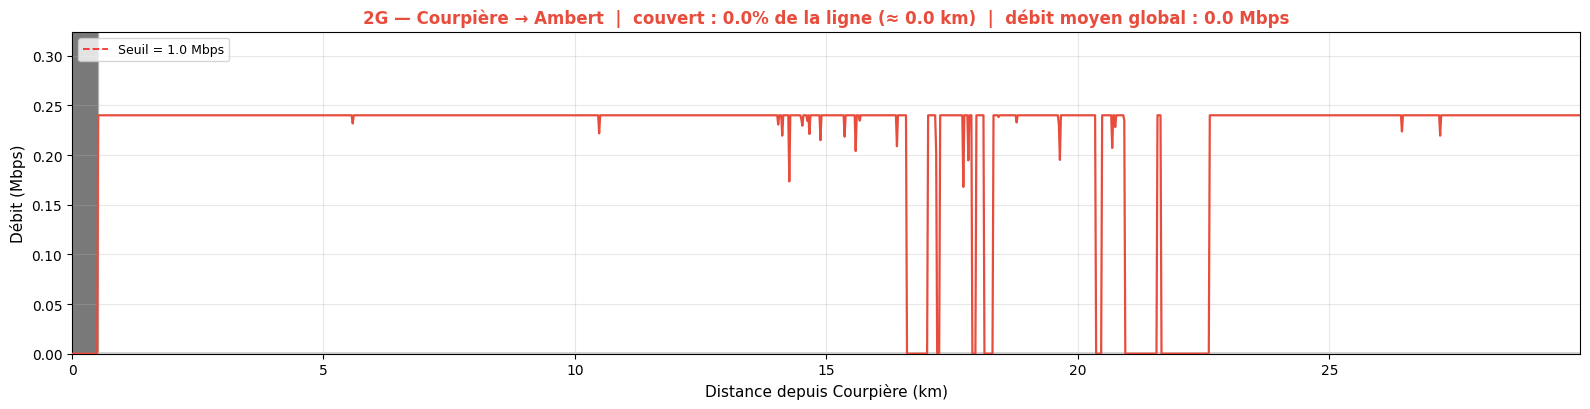

2G — tronçons couverts (seuil 1.0 Mbps) :
   Aucun tronçon couvert.
Sauvegardé : couverture_2G.png



In [13]:
plot_couverture_generation(pivot_debit, '2G', COLORS_GEN['2G'])


#### Couverture 3G


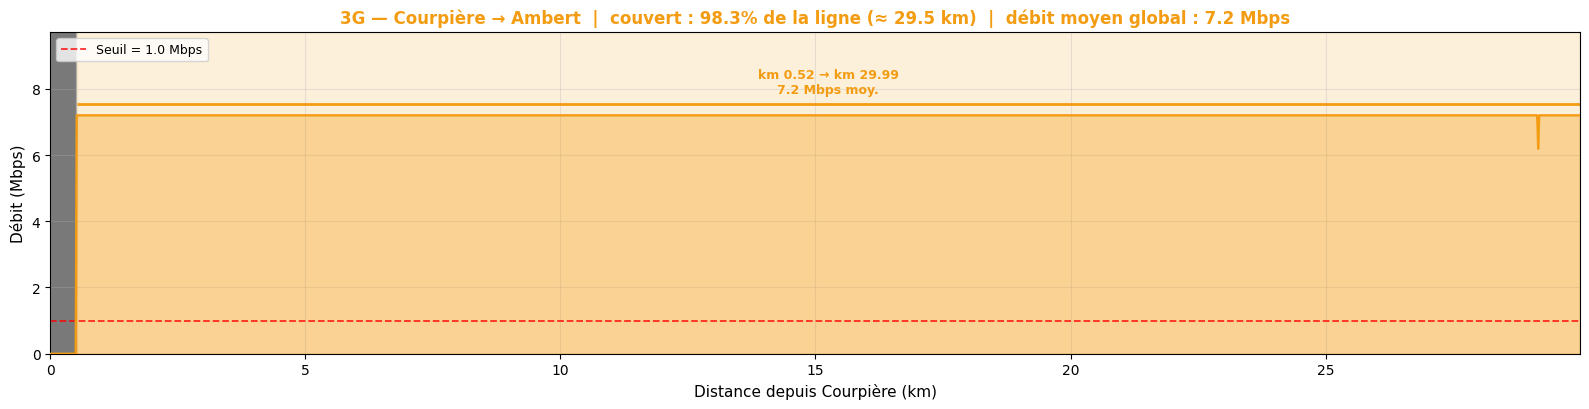

3G — tronçons couverts (seuil 1.0 Mbps) :
   km   0.52 → km  29.99  (29.47 km)  |  débit moyen :    7.2 Mbps
Sauvegardé : couverture_3G.png



In [14]:
plot_couverture_generation(pivot_debit, '3G', COLORS_GEN['3G'])


#### Couverture 4G


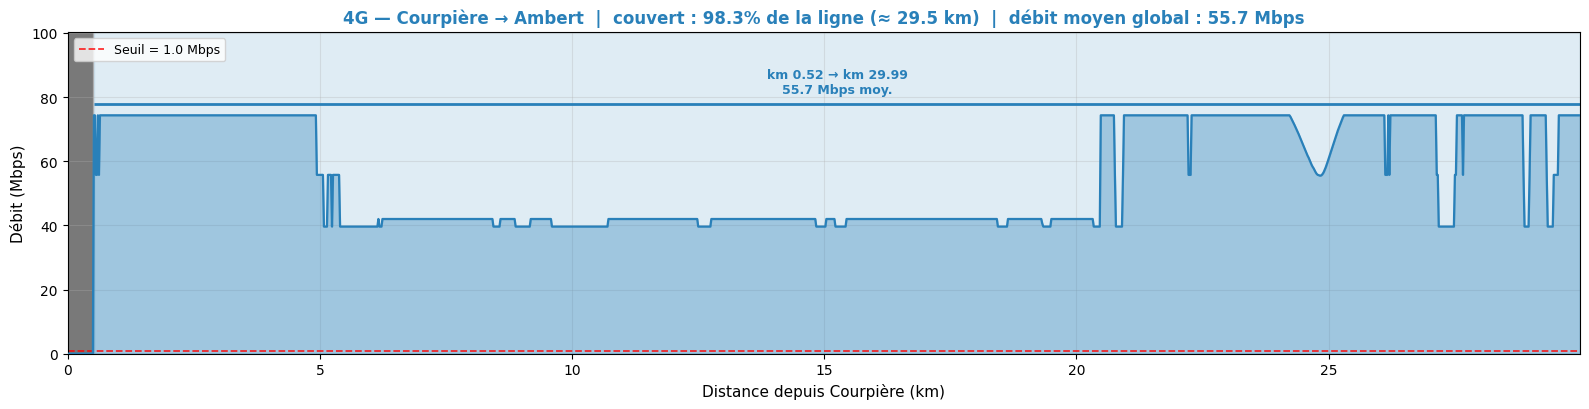

4G — tronçons couverts (seuil 1.0 Mbps) :
   km   0.52 → km  29.99  (29.47 km)  |  débit moyen :   55.7 Mbps
Sauvegardé : couverture_4G.png



In [15]:
plot_couverture_generation(pivot_debit, '4G', COLORS_GEN['4G'])


#### Couverture 5G


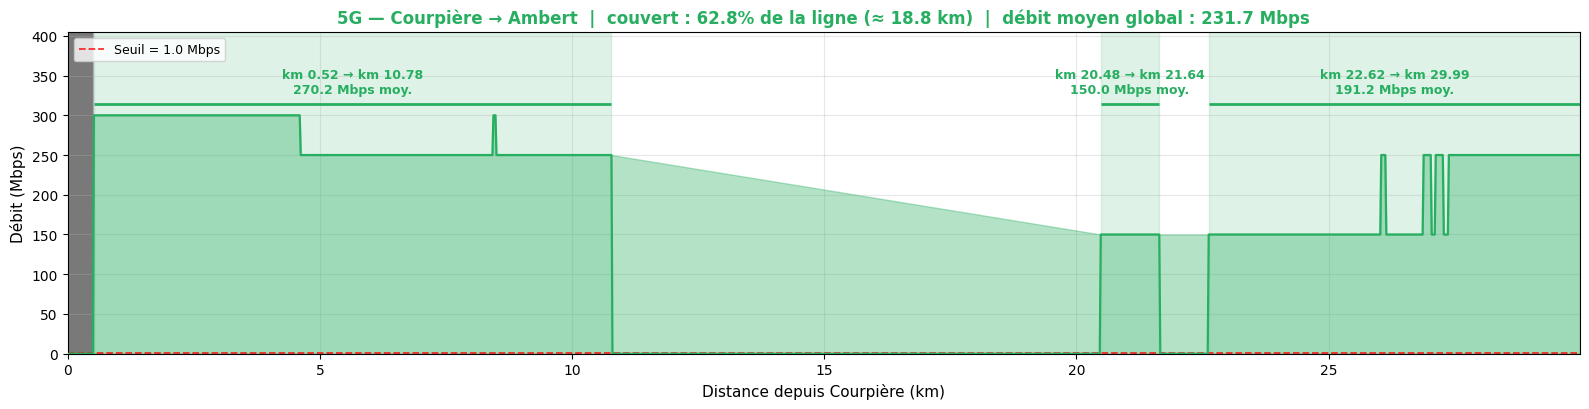

5G — tronçons couverts (seuil 1.0 Mbps) :
   km   0.52 → km  10.78  (10.26 km)  |  débit moyen :  270.2 Mbps
   km  20.48 → km  21.64  ( 1.16 km)  |  débit moyen :  150.0 Mbps
   km  22.62 → km  29.99  ( 7.36 km)  |  débit moyen :  191.2 Mbps
Sauvegardé : couverture_5G.png



In [16]:
plot_couverture_generation(pivot_debit, '5G', COLORS_GEN['5G'])


### Diagrammes altitude/distance par génération — couverture le long du relief

Même tracé que la carte "meilleure technologie" (altitude du terrain en fonction de la
distance), mais ici **un graphique par génération** : chaque point du trajet est colorié
selon que cette génération spécifique le couvre (≥ seuil) ou non, sans comparer aux autres
générations. Cela permet de voir si la couverture d'une techno suit un profil de terrain
particulier (ex. perdue en altitude, ou dans les creux).


In [17]:
def plot_altitude_generation(pivot_debit, gen, color, seuil=SEUIL_DEBIT_MBPS):
    """Trace altitude (m) vs distance (km), point couvert en couleur / non couvert en gris."""
    fig, ax = plt.subplots(figsize=(16, 3.5))

    if gen not in pivot_debit.columns:
        ax.text(0.5, 0.5, f'{gen} — pas de données', ha='center', va='center',
                transform=ax.transAxes, fontsize=12)
        return

    mask_tunnel = pivot_debit['in_tunnel']
    mask_ok     = (~mask_tunnel) & (pivot_debit[gen] >= seuil)
    mask_nok    = (~mask_tunnel) & (pivot_debit[gen] < seuil)

    ax.scatter(pivot_debit.loc[mask_ok, 'distance_km'],
               pivot_debit.loc[mask_ok, 'altitude_m'],
               c=color, s=14, alpha=0.9, label=f'{gen} couvert (≥ {seuil} Mbps)', zorder=3)
    ax.scatter(pivot_debit.loc[mask_nok, 'distance_km'],
               pivot_debit.loc[mask_nok, 'altitude_m'],
               c='lightgray', s=14, alpha=0.8, label='Non couvert', zorder=2)
    ax.scatter(pivot_debit.loc[mask_tunnel, 'distance_km'],
               pivot_debit.loc[mask_tunnel, 'altitude_m'],
               c='black', s=14, alpha=0.9, label='Tunnel', zorder=4)

    n_couv = mask_ok.sum()
    pct_couv = n_couv / len(pivot_debit) * 100

    ax.set_xlabel('Distance depuis Courpière (km)', fontsize=11)
    ax.set_ylabel('Altitude (m)', fontsize=11)
    ax.set_title(f'{gen} — Couverture le long du relief — Courpière → Ambert  |  couvert : {pct_couv:.1f}% de la ligne',
                 fontsize=12, fontweight='bold', color=color)
    ax.legend(fontsize=9, loc='upper left')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'altitude_{gen}.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Sauvegardé : altitude_{gen}.png\n")


#### Couverture 2G — vue altitude/relief


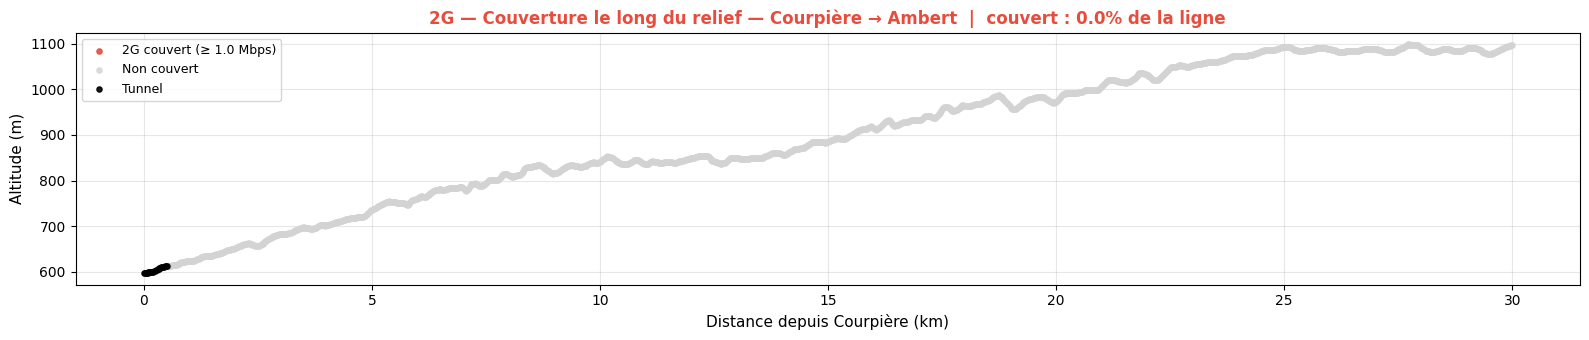

Sauvegardé : altitude_2G.png



In [18]:
plot_altitude_generation(pivot_debit, '2G', COLORS_GEN['2G'])


#### Couverture 3G — vue altitude/relief


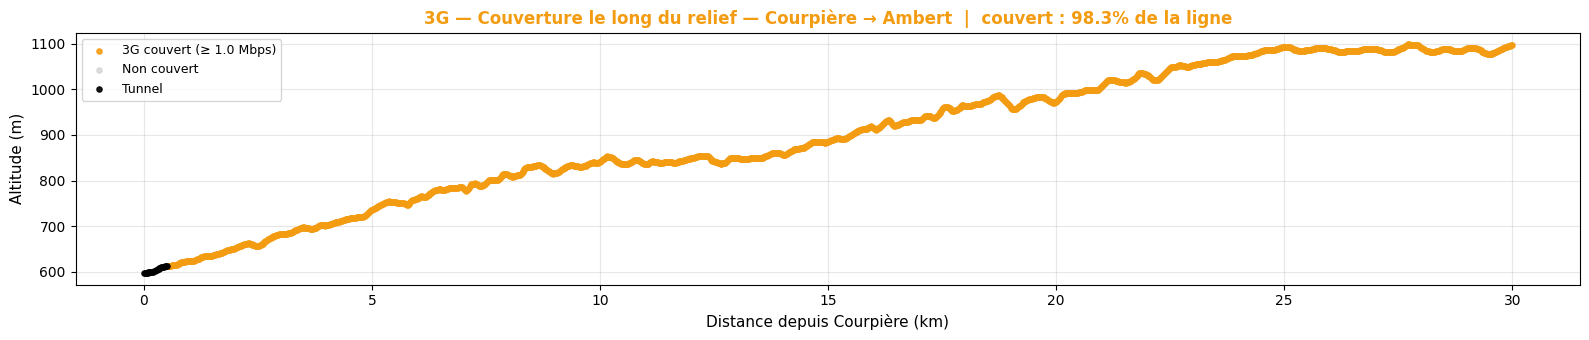

Sauvegardé : altitude_3G.png



In [19]:
plot_altitude_generation(pivot_debit, '3G', COLORS_GEN['3G'])


#### Couverture 4G — vue altitude/relief


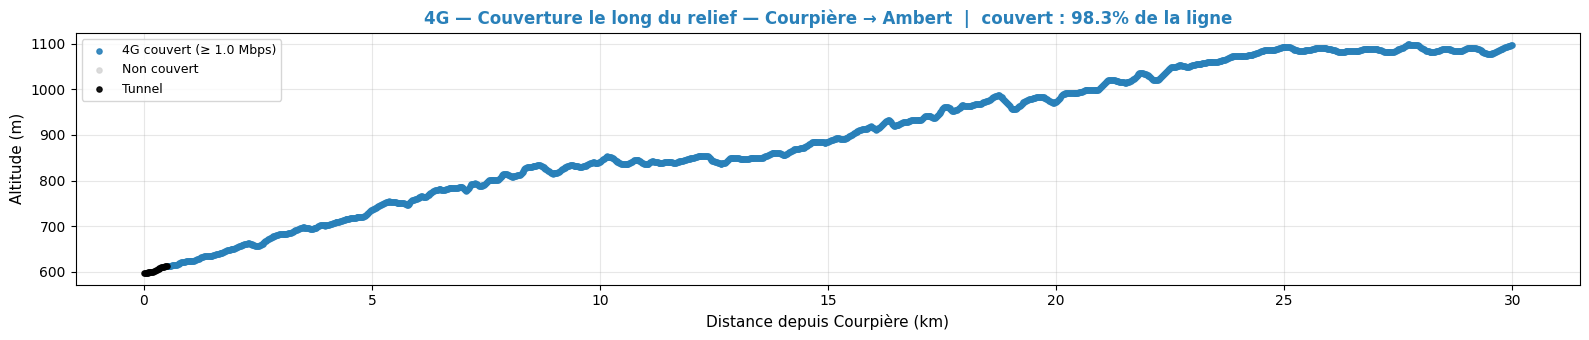

Sauvegardé : altitude_4G.png



In [20]:
plot_altitude_generation(pivot_debit, '4G', COLORS_GEN['4G'])


#### Couverture 5G — vue altitude/relief


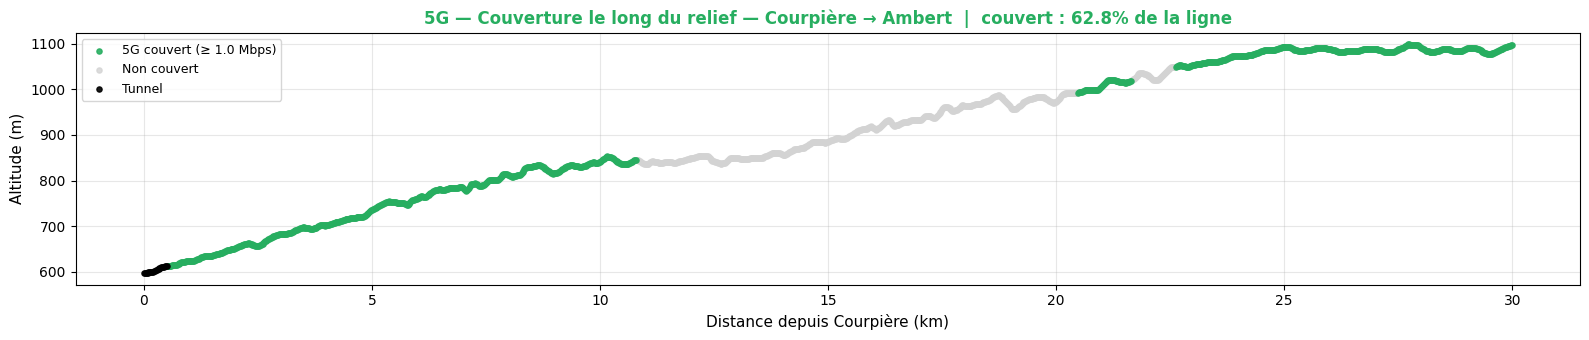

Sauvegardé : altitude_5G.png



In [21]:
plot_altitude_generation(pivot_debit, '5G', COLORS_GEN['5G'])


---
### Diagrammes de couverture combinée débit + latence

Au-delà du seuil débit seul (`SEUIL_DEBIT_MBPS`), on ajoute une condition de **latence**
(`rtt_ms`, le round-trip-time du pipeline — équivalent de la latence applicative).

Un point est considéré couvert pour une génération donnée si, **simultanément** :
- `debit_adj_mbps ≥ SEUIL_DEBIT_MBPS` (même seuil que la zone blanche, pour rester
  cohérent avec la Partie 1 — un seuil unique permet de comparer les générations entre
  elles sur un pied d'égalité, plutôt que des seuils différenciés par techno qui mesurent
  une notion différente : la qualité de service propre à chaque génération, cf. `qualite_ok`
  dans `enrich_data.py`) ;
- `rtt_ms < SEUIL_LATENCE_MS`.

Trois seuils de latence sont testés indépendamment (3 diagrammes séparés par seuil) :
**10 ms** (usage temps réel strict — sécurité ferroviaire, contrôle-commande),
**50 ms** (usage interactif standard — supervision, vidéo temps réel dégradée),
**100 ms** (usage tolérant — télémétrie, messagerie).

Le critère combiné (et non la latence seule) est utilisé : un lien à faible latence mais à
débit insuffisant n'est pas exploitable pour les fonctions critiques visées par FerroMobile,
donc l'isoler sans condition de débit n'aurait pas de sens opérationnel ici.

In [22]:
# Pivot RTT par génération (même structure que pivot_debit)
gen_rtt = df.groupby(['point_id', 'generation']).agg(
    best_debit = ('debit_adj_mbps', 'max'),
    best_rtt   = ('rtt_ms',         'min'),   # meilleur cas = latence la plus faible disponible
).reset_index()

pivot_rtt = gen_rtt.pivot_table(
    index='point_id', columns='generation', values='best_rtt', aggfunc='min'
)
pivot_rtt.columns = [f'{c}_rtt' for c in pivot_rtt.columns]

pivot_debit_rtt = pivot_debit.merge(pivot_rtt, on='point_id', how='left')

print("Aperçu colonnes RTT disponibles :", [c for c in pivot_debit_rtt.columns if c.endswith('_rtt')])
print(f"\nValeurs manquantes RTT (pas de mesure dispo, ex. tunnel) :")
for gen in ['2G','3G','4G','5G']:
    col = f'{gen}_rtt'
    if col in pivot_debit_rtt.columns:
        print(f"  {gen} : {pivot_debit_rtt[col].isna().sum()} points sans RTT mesuré")


Aperçu colonnes RTT disponibles : ['2G_rtt', '3G_rtt', '4G_rtt', '5G_rtt']

Valeurs manquantes RTT (pas de mesure dispo, ex. tunnel) :
  2G : 149 points sans RTT mesuré
  3G : 26 points sans RTT mesuré
  4G : 26 points sans RTT mesuré
  5G : 558 points sans RTT mesuré


In [23]:
def get_troncons_latence(pivot_debit_rtt, gen, seuil_debit, seuil_latence_ms, gap_max=GAP_MAX_KM):
    """Tronçons couverts : débit ≥ seuil_debit ET rtt_ms < seuil_latence_ms, hors tunnel."""
    rtt_col = f'{gen}_rtt'
    if gen not in pivot_debit_rtt.columns or rtt_col not in pivot_debit_rtt.columns:
        return []
    mask = (
        (pivot_debit_rtt[gen] >= seuil_debit) &
        (pivot_debit_rtt[rtt_col].notna()) &
        (pivot_debit_rtt[rtt_col] < seuil_latence_ms) &
        (~pivot_debit_rtt['in_tunnel'])
    )
    sub = pivot_debit_rtt.loc[mask, ['distance_km']].sort_values('distance_km').reset_index(drop=True)
    if sub.empty:
        return []
    troncons, start, prev = [], sub['distance_km'].iloc[0], sub['distance_km'].iloc[0]
    for d in sub['distance_km'].iloc[1:]:
        if d - prev > gap_max:
            troncons.append((start, prev))
            start = d
        prev = d
    troncons.append((start, prev))
    return troncons


def plot_couverture_latence(pivot_debit_rtt, seuil_latence_ms, seuil_debit=SEUIL_DEBIT_MBPS):
    """Une carte par seuil de latence : tronçons couverts (débit ET latence) par génération."""
    fig, ax = plt.subplots(figsize=(16, 4))

    y_positions = {'2G': 0, '3G': 1, '4G': 2, '5G': 3}
    for gen, y in y_positions.items():
        troncons = get_troncons_latence(pivot_debit_rtt, gen, seuil_debit, seuil_latence_ms)
        for (a, b) in troncons:
            width = max(b - a, 0.05)
            ax.barh(y, width, left=a, height=0.7, color=COLORS_GEN[gen],
                    edgecolor='white', linewidth=0.5, zorder=2)
        n_pts = sum(1 for _ in troncons)

    ax.set_yticks(list(y_positions.values()))
    ax.set_yticklabels(list(y_positions.keys()))
    ax.set_xlabel('Distance depuis Courpière (km)', fontsize=12)
    ax.set_title(
        f'Couverture combinée débit ≥ {seuil_debit} Mbps ET latence < {seuil_latence_ms} ms — par génération',
        fontsize=13, fontweight='bold')
    ax.set_xlim(DIST_MIN, DIST_MAX)
    ax.grid(True, alpha=0.3, axis='x')
    plt.tight_layout()
    fname = f'couverture_latence_{seuil_latence_ms}ms.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Sauvegardé : {fname}\n")

    print(f"Couverture par génération (débit ≥ {seuil_debit} Mbps ET rtt < {seuil_latence_ms} ms) :")
    for gen in ['2G','3G','4G','5G']:
        rtt_col = f'{gen}_rtt'
        if gen in pivot_debit_rtt.columns and rtt_col in pivot_debit_rtt.columns:
            mask = (
                (pivot_debit_rtt[gen] >= seuil_debit) &
                (pivot_debit_rtt[rtt_col].notna()) &
                (pivot_debit_rtt[rtt_col] < seuil_latence_ms) &
                (~pivot_debit_rtt['in_tunnel'])
            )
            n = mask.sum()
            pct = n / len(pivot_debit_rtt) * 100
            print(f"  {gen} : {n:4d} points ({pct:5.1f}% de la ligne)")


#### Couverture combinée — seuil latence < 10 ms (temps réel strict)

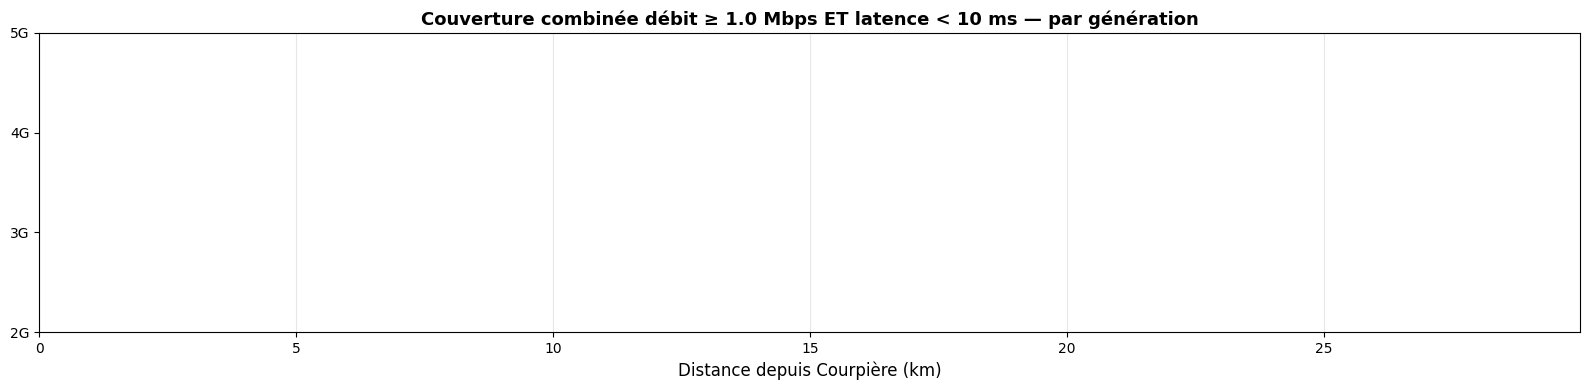

Sauvegardé : couverture_latence_10ms.png

Couverture par génération (débit ≥ 1.0 Mbps ET rtt < 10 ms) :
  2G :    0 points (  0.0% de la ligne)
  3G :    0 points (  0.0% de la ligne)
  4G :    0 points (  0.0% de la ligne)
  5G :    0 points (  0.0% de la ligne)


In [24]:
plot_couverture_latence(pivot_debit_rtt, seuil_latence_ms=10)

#### Couverture combinée — seuil latence < 50 ms (interactif standard)

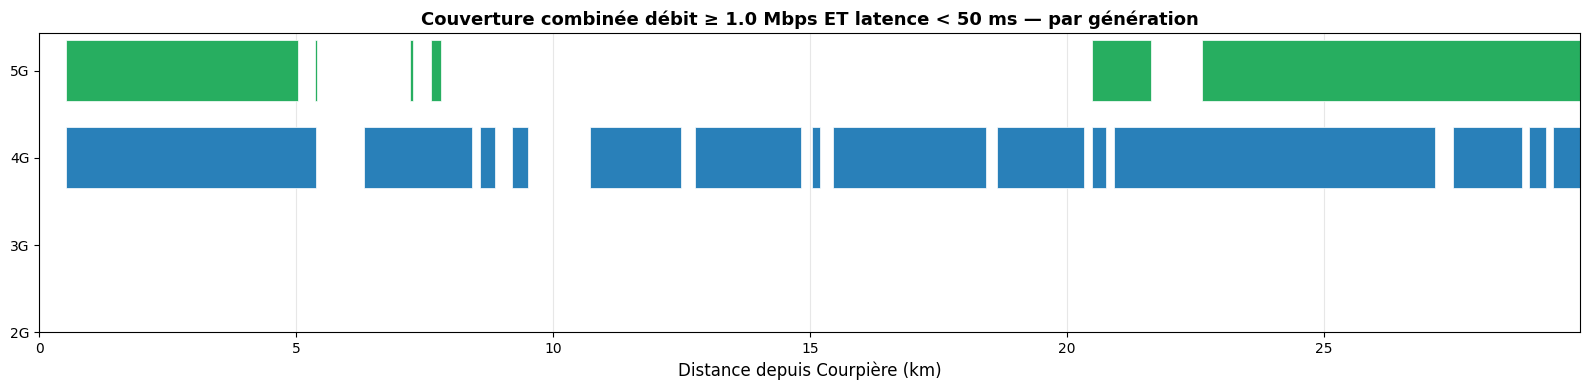

Sauvegardé : couverture_latence_50ms.png

Couverture par génération (débit ≥ 1.0 Mbps ET rtt < 50 ms) :
  2G :    0 points (  0.0% de la ligne)
  3G :    0 points (  0.0% de la ligne)
  4G : 1255 points ( 83.7% de la ligne)
  5G :  665 points ( 44.3% de la ligne)


In [25]:
plot_couverture_latence(pivot_debit_rtt, seuil_latence_ms=50)

#### Couverture combinée — seuil latence < 100 ms (tolérant)

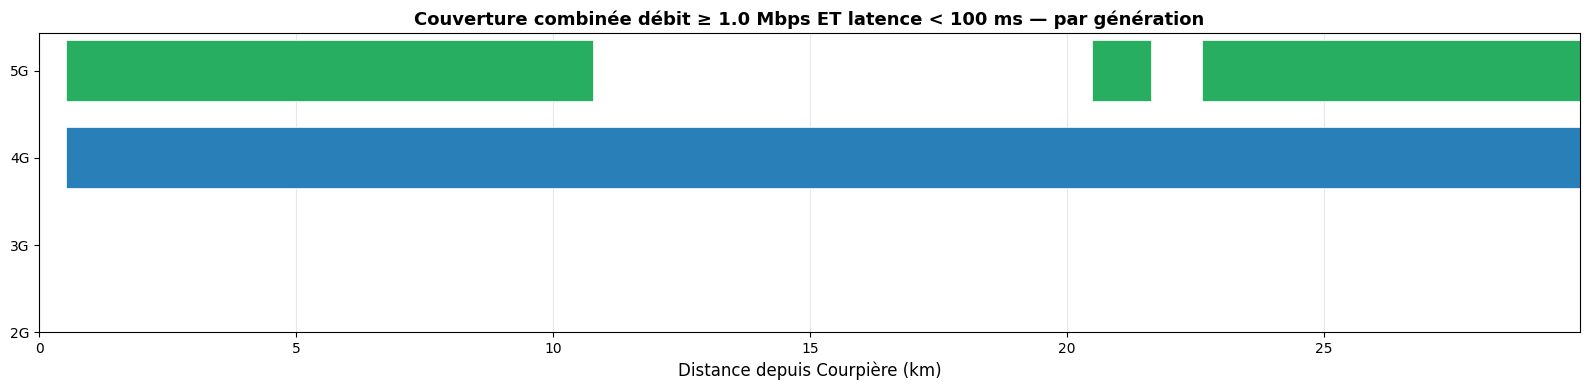

Sauvegardé : couverture_latence_100ms.png

Couverture par génération (débit ≥ 1.0 Mbps ET rtt < 100 ms) :
  2G :    0 points (  0.0% de la ligne)
  3G :    0 points (  0.0% de la ligne)
  4G : 1474 points ( 98.3% de la ligne)
  5G :  942 points ( 62.8% de la ligne)


In [26]:
plot_couverture_latence(pivot_debit_rtt, seuil_latence_ms=100)

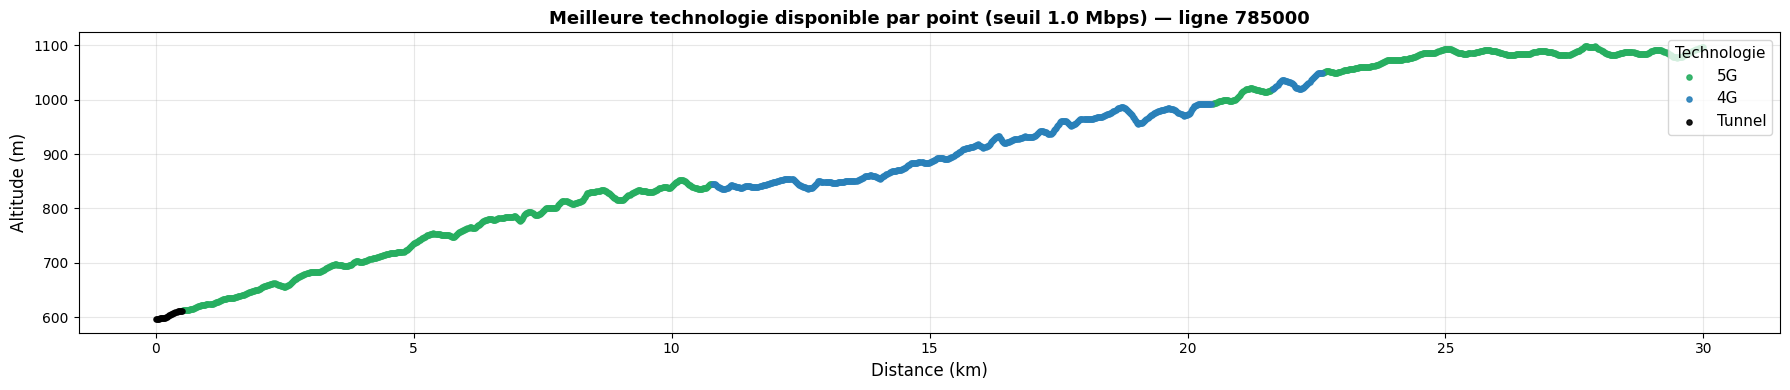


Distribution meilleure technologie par tronçon :
best_gen
5G        942
4G        532
Tunnel     26
Name: count, dtype: int64
  5G       :  942 points ( 62.8%) ≈ 18.8 km
  4G       :  532 points ( 35.5%) ≈ 10.6 km
  3G       :    0 points (  0.0%) ≈ 0.0 km
  2G       :    0 points (  0.0%) ≈ 0.0 km
  Tunnel   :   26 points (  1.7%) ≈ 0.5 km
  Aucune   :    0 points (  0.0%) ≈ 0.0 km


In [27]:
# Quelle est la meilleure génération couvrant chaque point (seuil appliqué) ?
def best_gen(row):
    if row.get('in_tunnel', False):
        return 'Tunnel'
    for gen in ['5G', '4G', '3G', '2G']:
        if gen in row and row[gen] >= SEUIL_DEBIT_MBPS:
            return gen
    return 'Aucune'

pivot_debit['best_gen'] = pivot_debit.apply(best_gen, axis=1)

COLORS_MAP = {
    '5G'    : '#27ae60',
    '4G'    : '#2980b9',
    '3G'    : '#f39c12',
    '2G'    : '#e74c3c',
    'Tunnel': 'black',
    'Aucune': 'lightgray',
}

fig, ax = plt.subplots(figsize=(18, 4))
for gen, color in COLORS_MAP.items():
    mask = pivot_debit['best_gen'] == gen
    if not mask.any():
        continue
    ax.scatter(pivot_debit.loc[mask, 'distance_km'],
               pivot_debit.loc[mask, 'altitude_m'],
               c=color, s=14, alpha=0.9, label=gen, zorder=3)

ax.set_xlabel('Distance (km)', fontsize=12)
ax.set_ylabel('Altitude (m)', fontsize=12)
ax.set_title(f'Meilleure technologie disponible par point (seuil {SEUIL_DEBIT_MBPS} Mbps) — ligne 785000',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11, title='Technologie', title_fontsize=11, loc='upper right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('couverture_carte_best_gen.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nDistribution meilleure technologie par tronçon :")
print(pivot_debit['best_gen'].value_counts())
for gen in ['5G','4G','3G','2G','Tunnel','Aucune']:
    n   = (pivot_debit['best_gen'] == gen).sum()
    pct = n / len(pivot_debit) * 100
    km  = n * 0.02   # points espacés de ~20m
    print(f"  {gen:8s} : {n:4d} points ({pct:5.1f}%) ≈ {km:.1f} km")


## Tableau récapitulatif


In [28]:
print("=" * 65)
print(f"{'Technologie':<12} {'Points couverts':>16} {'% ligne':>8} {'Débit moy (Mbps)':>17} {'Débit max (Mbps)':>17}")
print("=" * 65)
for gen in ['2G','3G','4G','5G']:
    if gen not in pivot_debit.columns:
        continue
    mask = (pivot_debit[gen] >= SEUIL_DEBIT_MBPS) & (~pivot_debit['in_tunnel'])
    n    = mask.sum()
    pct  = n / len(pivot_debit) * 100
    moy  = pivot_debit.loc[mask, gen].mean()
    mx   = pivot_debit.loc[mask, gen].max()
    print(f"{gen:<12} {n:>16} {pct:>8.1f} {moy:>17.1f} {mx:>17.1f}")
print("=" * 65)
print(f"{'Tunnel':<12} {pivot_debit['in_tunnel'].sum():>16} "
      f"{pivot_debit['in_tunnel'].mean()*100:>8.1f}  {'—':>17} {'—':>17}")


Technologie   Points couverts  % ligne  Débit moy (Mbps)  Débit max (Mbps)
2G                          0      0.0               nan               nan
3G                       1474     98.3               7.2               7.2
4G                       1474     98.3              55.7              74.3
5G                        942     62.8             231.7             300.0
Tunnel                     26      1.7                  —                 —


In [29]:
# ── Zone Blanche par puissance de signal (RSRP/RSSI) ─────────────────────────
# Complément à la Partie 1 (seuil débit) : même logique, critère radio différent.
#
# Seuils standards 3GPP / ARCEP :
#   RSRP (4G/5G LTE) : < -110 dBm → couverture insuffisante (edge-of-coverage)
#   RSSI (2G/3G)      : < -95 dBm  → signal trop faible pour service fiable
#
# Règle appliquée (alignée sur la logique enrich_data.py) :
#   - Générations cellulaires uniquement (2G/3G/4G/5G)
#   - Tunnel → zone_blanche_signal = 1 indépendamment de la puissance
#   - Hors tunnel → zone_blanche_signal = 1 si MAX(puissance cellulaire) < seuil

SEUIL_RSRP_DBM = -110.0   # dBm — seuil RSRP LTE (3GPP TS 38.133)
SEUIL_RSSI_DBM = -95.0    # dBm — seuil RSSI GSM/UMTS
CELL_GENERATIONS = ['2G', '3G', '4G', '5G']

# Détection de la colonne puissance disponible dans le dataset
signal_col = None
for candidate in ['rsrp_dbm', 'rssi_dbm', 'signal_power_dbm', 'rx_level_dbm']:
    if candidate in df.columns:
        signal_col = candidate
        break

if signal_col is None:
    print("⚠ Aucune colonne de puissance signal trouvée.")
    print("  Colonnes disponibles (filtre 'db') :", [c for c in df.columns if 'db' in c.lower()])
else:
    print(f"✓ Colonne puissance utilisée : {signal_col}")

    # Seuil adaptatif selon le type de colonne détecté
    SEUIL_SIGNAL = SEUIL_RSRP_DBM if 'rsrp' in signal_col else SEUIL_RSSI_DBM

    # Meilleure puissance disponible parmi les antennes cellulaires hors tunnel
    mask_cell_signal = df['generation'].isin(CELL_GENERATIONS) & (~df['in_tunnel'])

    best_signal_cell = (
        df.loc[mask_cell_signal]
          .groupby('point_id')[signal_col]
          .max()   # max en dBm = meilleur signal (moins négatif)
    )

    # Agrégation par point (réutilise la structure de by_point_zb)
    by_point_sig = df.groupby('point_id').agg(
        lat         = ('lat',         'first'),
        lon         = ('lon',         'first'),
        distance_km = ('distance_km', 'first'),
        altitude_m  = ('altitude_m',  'first'),
        in_tunnel   = ('in_tunnel',   'max'),
    ).reset_index()

    by_point_sig['best_signal'] = by_point_sig['point_id'].map(best_signal_cell)
    # Aucun signal cellulaire disponible → traité comme zone blanche
    by_point_sig['best_signal'] = by_point_sig['best_signal'].fillna(-999.0)

    # Classification par seuil puissance — tunnel toujours prioritaire
    by_point_sig['zone_blanche_signal'] = np.where(
        by_point_sig['in_tunnel'],
        1,
        (by_point_sig['best_signal'] < SEUIL_SIGNAL).astype(int)
    )

    by_point_sig = by_point_sig.sort_values('distance_km').reset_index(drop=True)

    n_total_s    = len(by_point_sig)
    n_blanche_s  = by_point_sig['zone_blanche_signal'].sum()
    n_couverte_s = n_total_s - n_blanche_s

    print(f"\nSeuil puissance utilisé : {SEUIL_SIGNAL} dBm ({signal_col})")
    print(f"Zone couverte (signal)  : {n_couverte_s:4d} points ({n_couverte_s/n_total_s*100:.1f}%)")
    print(f"Zone blanche  (signal)  : {n_blanche_s:4d}  points ({n_blanche_s/n_total_s*100:.1f}%)")

    # ── Comparaison seuil-débit vs seuil-signal ───────────────────────────────
    # (nécessite que by_point_zb soit déjà calculé dans la cellule précédente)
    if 'by_point_zb' in dir():
        compare = by_point_zb[['point_id', 'zone_blanche_seuil']].merge(
            by_point_sig[['point_id', 'zone_blanche_signal']], on='point_id'
        )
        accord_sig = (compare['zone_blanche_seuil'] == compare['zone_blanche_signal']).mean()
        print(f"\nAccord seuil-débit vs seuil-signal : {accord_sig*100:.1f}%")
        n_desaccord = (compare['zone_blanche_seuil'] != compare['zone_blanche_signal']).sum()
        if n_desaccord > 0:
            print(f"⚠ {n_desaccord} points classés différemment entre les deux critères")
            print("  → Ces points ont un signal fort mais débit faible (ou l'inverse)")
            print("  → À examiner : congestion réseau, modulation dégradée, interférence")

    # ── Visualisation : profil puissance le long de la ligne ──────────────────
    fig, ax = plt.subplots(figsize=(16, 4))

    ax.fill_between(by_point_sig['distance_km'], by_point_sig['best_signal'],
                    alpha=0.25, color='darkorange')
    ax.plot(by_point_sig['distance_km'], by_point_sig['best_signal'],
            color='darkorange', lw=1.3, label=f'Meilleur {signal_col}')

    ax.axhline(SEUIL_SIGNAL, color='red', lw=1.5, ls='--',
               label=f'Seuil = {SEUIL_SIGNAL} dBm')

    mask_blanche_s = by_point_sig['zone_blanche_signal'] == 1
    ax.scatter(by_point_sig.loc[mask_blanche_s, 'distance_km'],
               by_point_sig.loc[mask_blanche_s, 'best_signal'],
               color='crimson', s=14, zorder=4, label='Zone blanche (signal)')

    ax.set_xlabel('Distance (km)', fontsize=12)
    ax.set_ylabel(f'{signal_col} (dBm)', fontsize=12)
    ax.set_title(f'Puissance signal max disponible — seuil zone blanche ({SEUIL_SIGNAL} dBm)',
                 fontsize=13, fontweight='bold')
    ax.legend(fontsize=11, loc='upper right')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('zone_blanche_signal_profil.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Sauvegardé : zone_blanche_signal_profil.png")

⚠ Aucune colonne de puissance signal trouvée.
  Colonnes disponibles (filtre 'db') : ['perte_db', 'snr_db', 'snr_adjusted_db', 'delta_snr_db', 'atten_pluie_db_km']


In [33]:
# ── Visualisation : Infrastructure et réseau mobile Courpière–Ambert ──

import folium
import pandas as pd
import numpy as np
from folium.plugins import MarkerCluster
from IPython.display import display

df_map = df.drop_duplicates(subset=['point_id']).sort_values('distance_km').reset_index(drop=True)
df_ant = df.drop_duplicates(subset=['ant_id'])

# ── Couleurs opérateurs ─────────────────────────────────────────────────────
OPERATEUR_COLORS = {
    'ORANGE': 'orange',
    'SFR': 'red',
    'BOUYGUES TELECOM': 'blue',
    'FREE MOBILE': 'green',
}

# ── Icônes (FontAwesome correct pour Folium) ────────────────────────────────
TECH_ICONS = {
    '2G': 'signal',
    '3G': 'signal',
    '4G': 'signal',
    '5G': 'bolt',
}

# ── Centre carte ────────────────────────────────────────────────────────────
center_lat = df_map['lat'].mean()
center_lon = df_map['lon'].mean()

m = folium.Map(
    location=[center_lat, center_lon],
    zoom_start=11,
    tiles='CartoDB positron'
)

# ── Tracé ligne ferroviaire ────────────────────────────────────────────────
coords_ligne = df_map[['lat', 'lon']].dropna().values.tolist()

folium.PolyLine(
    coords_ligne,
    color='royalblue',
    weight=3,
    opacity=0.9,
    tooltip='Ligne Courpière – Ambert'
).add_to(m)

# ── Tunnels ────────────────────────────────────────────────────────────────
df_tunnels = df_map[df_map.get('in_tunnel', False) == True]

for _, row in df_tunnels.iterrows():
    folium.CircleMarker(
        location=[row['lat'], row['lon']],
        radius=5,
        color='black',
        fill=True,
        fill_color='black',
        fill_opacity=0.8,
        tooltip=f"Tunnel — {row['distance_km']:.1f} km"
    ).add_to(m)

# ── Antennes ────────────────────────────────────────────────────────────────
ant_cluster = MarkerCluster(name='Antennes').add_to(m)

for _, row in df_ant.iterrows():

    operateur = str(row.get('operateur', 'INCONNU')).upper()
    generation = str(row.get('generation', '4G')).upper()

    color = OPERATEUR_COLORS.get(operateur, 'gray')
    icon_name = TECH_ICONS.get(generation, 'signal')

    if pd.isna(row.get('ant_lat')) or pd.isna(row.get('ant_lon')):
        continue

    folium.Marker(
        location=[row['ant_lat'], row['ant_lon']],
        icon=folium.Icon(
            color=color,
            icon=icon_name,
            prefix='fa'
        ),
        tooltip=f"{operateur} — {generation} — {row.get('bande_mhz', 'N/A')} MHz"
    ).add_to(ant_cluster)

# ── Passages à niveau ───────────────────────────────────────────────────────
if 'passage_niveau' in df_map.columns:
    df_pn = df_map[df_map['passage_niveau'] == True]

    for _, row in df_pn.iterrows():
        folium.Marker(
            location=[row['lat'], row['lon']],
            icon=folium.Icon(color='black', icon='times', prefix='fa'),
            tooltip=f"Passage à niveau — {row['distance_km']:.1f} km"
        ).add_to(m)

# ── Villes ──────────────────────────────────────────────────────────────────
villes = [
    {'nom': 'Courpière', 'lat': 45.745, 'lon': 3.548},
    {'nom': 'Ambert',    'lat': 45.550, 'lon': 3.737},
]

for v in villes:
    folium.Marker(
        location=[v['lat'], v['lon']],
        icon=folium.Icon(color='darkblue', icon='building', prefix='fa'),
        tooltip=v['nom']
    ).add_to(m)

# ── Légende ────────────────────────────────────────────────────────────────
legend_html = """
<div style="position:fixed; bottom:30px; left:30px; z-index:1000;
     background:white; padding:12px 16px; border-radius:8px;
     border:1px solid #ccc; font-size:12px; line-height:1.8;">
  <b>Opérateurs</b><br>
  <span style="color:orange">■</span> Orange<br>
  <span style="color:red">■</span> SFR<br>
  <span style="color:blue">■</span> Bouygues Telecom<br>
  <span style="color:green">■</span> Free Mobile<br>
  <br>
  <b>Infrastructure</b><br>
  <span style="color:royalblue">━</span> Ligne ferroviaire<br>
  <span style="color:black">●</span> Tunnel<br>
  <span style="color:black">✕</span> Passage à niveau<br>
  <br>
  <b>Technologies</b><br>
  2G / 3G / 4G / 5G
</div>
"""

m.get_root().html.add_child(folium.Element(legend_html))

folium.LayerControl().add_to(m)

# ── Output ──────────────────────────────────────────────────────────────────
m.save('carte_infrastructure_reseau.html')
display(m)

print("Sauvegardée : carte_infrastructure_reseau.html")

Sauvegardée : carte_infrastructure_reseau.html
